# 02 - Parameter Sweeps with tProc v2

**Objective:** Learn how to automate parameter variation (sweeps) to create 1D and 2D scans, and understand how to retrieve the actual swept values.

## 1. Setup

In [ ]:
# Standard imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import logging

from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D, QickSpan

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# Connect to the board (adjust the path to your firmware)
BITSTREAM_PATH = '/path/to/your/firmware.bit'  # <--- CHANGE THIS
soc = QickSoc(BITSTREAM_PATH)
soccfg = soc

# Define hardware channels
GEN_CH = 0
RO_CH = 0

## 2. Understanding Sweeps

In QICK, a **sweep** is an automatic variation of a parameter across multiple experiment shots. The tProc handles the looping internally, eliminating Python-to-FPGA communication latency.

Key components:
- **`add_loop(name, steps)`** - Defines a loop that will run `steps` times
- **`QickSweep1D(loop_name, start, stop)`** - Creates a linear sweep from `start` to `stop` over the loop iterations
- **`get_pulse_param(pulse_name, param, as_array=True)`** - Retrieves the actual swept values (after hardware quantization)

## 3. A Simple 1D Sweep

Let's sweep the phase of a flat-top pulse from -360° to 720° while also sweeping the gain from 0 to 1.

  0%|          | 0/10 [00:00<?, ?it/s]

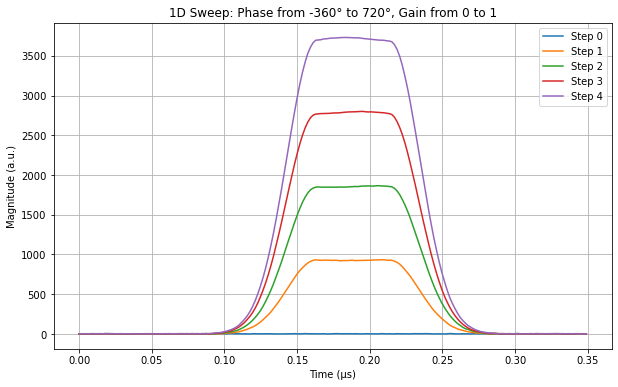

Swept phase values (degrees): [-360.  -90.  180.  450.  720.]
Swept gain values: [0.         0.24995422 0.49990844 0.74986266 0.99981688]


In [2]:
class SimpleSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define the loop that controls our sweep
        self.add_loop("my_sweep", self.cfg["steps"])

        # Define a Gaussian envelope for pulse shaping
        self.add_gauss(ch=gen_ch, name="ramp", 
                       sigma=cfg['ramp_len']/10, 
                       length=cfg['ramp_len'], 
                       even_length=True)
        
        # Define the pulse with swept parameters
        self.add_pulse(ch=gen_ch, name="swept_pulse", 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=cfg['flat_len'],
                       phase=QickSweep1D("my_sweep", -360, 720),  # Sweep from -360° to 720°
                       gain=QickSweep1D("my_sweep", 0.0, 1.0)      # Sweep gain from 0 to 1
                      )

        # Configure readout
        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="swept_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Configuration
config = {
    'steps': 5,                     # Number of sweep points
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,                    # MHz
    'trig_time': 0.25,              # µs
    'ro_len': 0.35,                 # µs
    'flat_len': 0.05,               # µs (flat segment duration)
    'ramp_len': 0.2                 # µs (ramp duration)
}

# Run the sweep
prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Plot magnitude for each sweep step
plt.figure(figsize=(10, 6))
for i, iq_point in enumerate(iq_data[0]):
    plt.plot(time_axis, np.abs(iq_point.dot([1,1j])), label=f"Step {i}")
plt.legend()
plt.xlabel('Time (µs)')
plt.ylabel('Magnitude (a.u.)')
plt.title('1D Sweep: Phase from -360° to 720°, Gain from 0 to 1')
plt.grid(True)
plt.show()

# Retrieve the actual swept values
phases = prog.get_pulse_param('swept_pulse', 'phase', as_array=True)
gains = prog.get_pulse_param('swept_pulse', 'gain', as_array=True)
print(f"Swept phase values (degrees): {phases}")
print(f"Swept gain values: {gains}")

**Explanation:**
- `add_loop("my_sweep", steps)` creates a loop. Any parameter wrapped in `QickSweep1D()` will vary across this loop.
- The tProc automatically:
  1. Updates the waveform parameters for each step
  2. Executes the `_body()` code
  3. Loops until all steps are complete
- `get_pulse_param()` returns the **actual** values after quantization, which may differ slightly from the requested values due to hardware precision limits.

## 4. 2D Sweeps with Nested Loops

For multi-dimensional scans, we can nest loops. The order of `add_loop()` calls determines the nesting order (first declared is outermost).

In [3]:
class Sweep2DProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Two nested loops: loop1 is outer, loop2 is inner
        self.add_loop("loop1", self.cfg["steps1"])
        self.add_loop("loop2", self.cfg["steps2"])

        # Define pulse with a 2D sweep
        self.add_gauss(ch=gen_ch, name="ramp", 
                       sigma=cfg['ramp_len']/10, 
                       length=cfg['ramp_len'], 
                       even_length=True)
        
        self.add_pulse(ch=gen_ch, name="pulse_2d", 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'])

        # Configure readout
        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="pulse_2d", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# 2D sweep: Gain varies in both loops
config_2d = {
    'steps1': 50,
    'steps2': 100,
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,
    'trig_time': 0.25,
    'ro_len': 0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2,
    'phase': 0,
    # Gain starts at 0.4. Increases by 0.5 in loop1, and by 0.1 in loop2
    'gain': 0.4 + QickSpan("loop1", 0.5) + QickSpan("loop2", 0.1)
}

# Run the 2D sweep
prog = Sweep2DProgram(soccfg, reps=100, final_delay=1.0, cfg=config_2d)
iq_data = prog.acquire(soc, rounds=1)

# Get the actual gain values as a 2D array
gains_2d = prog.get_pulse_param('pulse_2d', 'gain', as_array=True)
print(f"Shape of gain grid: {gains_2d.shape}")
print(f"First row (first 10 values): {gains_2d[0, :10]}")
print(f"Last row (first 10 values): {gains_2d[-1, :10]}")

  0%|          | 0/500000 [00:00<?, ?it/s]

Shape of gain grid: (50, 100)
First row (first 10 values): [0.39998779 0.40096441 0.40194104 0.40291766 0.40389428 0.4048709
 0.40584752 0.40682415 0.40780077 0.40877739]
Last row (first 10 values): [0.89946896 0.90044558 0.90142221 0.90239883 0.90337545 0.90435207
 0.90532869 0.90630532 0.90728194 0.90825856]


**Explanation of QickSpan:**
- `QickSpan(loop_name, increment)` adds an increment to a parameter each time the loop iterates
- The total parameter value is the sum of all spans across nested loops
- In this example, `gain = 0.4 + loop1_span + loop2_span`
- This creates a 2D grid where gain increases in both dimensions

**Loop order and data shape:**
- Data shape is `(reps, loop1, loop2, readout_length, I/Q)`
- The outermost loop (loop1) changes slowest

## 5. Sweeping Pulse Length

You can sweep any numeric parameter, including pulse lengths and delays.

  0%|          | 0/10 [00:00<?, ?it/s]

Flat segment lengths (µs): [0.05086263 0.07527669 0.09969076 0.12410482 0.14851888]
Total pulse lengths (µs): [0.15258789 0.17700195 0.20141602 0.22583008 0.25024414]


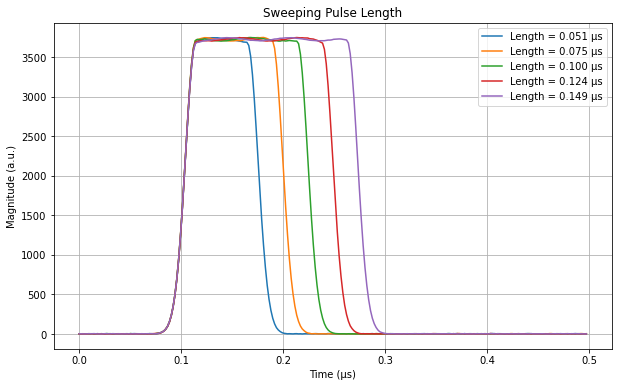

In [4]:
class LengthSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("length_sweep", self.cfg["steps"])

        # Gaussian envelope (fixed parameters)
        self.add_gauss(ch=gen_ch, name="ramp", 
                       sigma=cfg['ramp_len']/10, 
                       length=cfg['ramp_len'], 
                       even_length=True)
        
        # Flat-top pulse with swept length
        self.add_pulse(ch=gen_ch, name="len_pulse", 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=QickSweep1D("length_sweep", 0.05, 0.15),  # Sweep from 50ns to 150ns
                       phase=0,
                       gain=cfg['gain']
                      )

        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="len_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Configuration
config_len = {
    'steps': 5,
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,
    'trig_time': 0.25,
    'ro_len': 0.5,
    'ramp_len': 0.1,
    'gain': 1.0
}

# Run the length sweep
prog = LengthSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config_len)
iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Get the actual length values
lengths = prog.get_pulse_param('len_pulse', 'length', as_array=True)
total_lengths = prog.get_pulse_param('len_pulse', 'total_length', as_array=True)
print(f"Flat segment lengths (µs): {lengths}")
print(f"Total pulse lengths (µs): {total_lengths}")

# Plot results
plt.figure(figsize=(10, 6))
for i, iq_point in enumerate(iq_data[0]):
    plt.plot(time_axis, np.abs(iq_point.dot([1,1j])), label=f"Length = {lengths[i]:.3f} µs")
plt.legend()
plt.xlabel('Time (µs)')
plt.ylabel('Magnitude (a.u.)')
plt.title('Sweeping Pulse Length')
plt.grid(True)
plt.show()

**Note on pulse lengths:**
- `length` refers to the flat segment duration (for flat-top pulses)
- `total_length` includes the rise and fall times
- Both can be swept independently

## 6. Inspecting Sweep Parameters

You can list all available parameters for a pulse and retrieve their values.

In [5]:
# List all parameters for the pulse
print("Available parameters for 'len_pulse':")
print(prog.list_pulse_params('len_pulse'))

# Get all swept values as a dictionary
# This is useful for saving experiment metadata
swept_values = {}
for param in ['length', 'total_length', 'gain', 'phase', 'freq']:
    try:
        swept_values[param] = prog.get_pulse_param('len_pulse', param, as_array=True)
    except:
        pass  # Parameter not swept or not available

print("\nSwept values:")
for param, values in swept_values.items():
    print(f"  {param}: {values}")

Available parameters for 'len_pulse':
['length', 'freq', 'phase', 'gain', 'total_length']

Swept values:
  length: [0.05086263 0.07527669 0.09969076 0.12410482 0.14851888]
  total_length: [0.15258789 0.17700195 0.20141602 0.22583008 0.25024414]
  gain: 1.0
  phase: 0.0
  freq: 500.00000061035155


## 7. Summary

You have learned:
- How to create 1D sweeps using `add_loop()` and `QickSweep1D`
- How to create 2D sweeps using nested loops and `QickSpan`
- How to sweep pulse lengths and other parameters
- How to retrieve the actual swept values using `get_pulse_param()`

**Key concepts:**
- Sweeps are executed entirely on the tProc, eliminating Python-FPGA latency
- Loop order determines the data shape (first declared = outermost)
- `QickSpan` allows building complex sweeps from simple components
- Always use `get_pulse_param()` to get the actual quantized values for accurate analysis

**Next steps:** Proceed to [`03_Advanced_Timing.ipynb`](./03_Advanced_Timing.ipynb) to learn about timeline management, `delay` vs `wait`, and avoiding timing pitfalls.